# Preprocessing Pipeline
*In this notebook we will cleanse our data.  
The process will include HTML tag removal, lowercasing, punctuation & stopword removal and lemmatization.*  

The notebook will demonstrate how the data looks before, and after each preprocessing step.  

***Prerequisite***: run the `download_nltk_data.py` from the project's root once prior to running this notebook.

**0. Setup**  

We load the dataset, prepare sample reviews, and define helpers used across all preprocessing steps.

In [1]:
import sys
from importlib import reload
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd
import textwrap

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import FIGURES_DIR, PREPROCESSED_DATA_PATH, RAW_DATA_PATH
import src.preprocessing as prep

reload(prep)

df = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} reviews\n")

# Raw samples used for preprocessing demonstrations
sample_pos = df[df['sentiment'] == 'positive']['review'].iloc[0]
sample_neg = df[df['sentiment'] == 'negative']['review'].iloc[0]

# Readable display helper: clip text to `chars` and wrap to `width`
snippet_chars = 1000
def display_snippet(text: str, chars: Optional[int] = None, width: int = 120) -> str:
    limit = snippet_chars if chars is None else chars
    return textwrap.fill(text[:limit], width=width)

print(f"=== SAMPLE POSITIVE REVIEW (first {snippet_chars} chars) ===")
print(display_snippet(sample_pos))
print(f"\n=== SAMPLE NEGATIVE REVIEW (first {snippet_chars} chars) ===")
print(display_snippet(sample_neg))

Dataset loaded: 50,000 reviews

=== SAMPLE POSITIVE REVIEW (first 1000 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses
mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so
privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians,
Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are ne

**1. Remove HTML tags**  

IMDB reviews contain raw HTML tags like `<br />`. We strip these tags before analysis.  
The tags increase token count and add noise without adding useful signal.

In [2]:
print(f"=== BEFORE HTML removal (first {snippet_chars} chars) ===")
print(display_snippet(sample_pos))
print(f"\n=== AFTER HTML removal (first {snippet_chars} chars) ===")
print(display_snippet(prep.remove_html_tags(sample_pos)))

=== BEFORE HTML removal (first 1000 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses
mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so
privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians,
Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would
sa

**2. Lowercase**  

Normalizes casing so that `"Good"`, `"GOOD"`, and `"good"` map to the same token.  
This step ensures a consistent vocabulary and avoids duplicate forms of the same word.

In [3]:
after_html = prep.remove_html_tags(sample_pos)
print(f"=== BEFORE Lowercasing (first {snippet_chars} chars) ===")
print(display_snippet(after_html))
print(f"\n=== AFTER Lowercasing (first {snippet_chars} chars) ===")
print(display_snippet(prep.to_lowercase(after_html)))

=== BEFORE Lowercasing (first 1000 chars) ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of
violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show
pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ
as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an
experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the
agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so
scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show
is due 

**3. Remove special characters (punctuation & numbers)**  

Punctuation and digits contribute nothing to a bag-of-words model.  
Keeping them would bloat the vocabulary with tokens like `"!!!"` or `"2024"` that appear rarely and carry no transferable meaning.  
After this step we are keeping only letters and spaces.


In [4]:
after_lower = prep.to_lowercase(prep.remove_html_tags(sample_pos))
print(f"=== BEFORE Special character removal (first {snippet_chars} chars) ===")
print(display_snippet(after_lower))
print(f"\n=== AFTER Special character removal (first {snippet_chars} chars) ===")
print(display_snippet(prep.remove_special_characters(after_lower)))

=== BEFORE Special character removal (first 1000 chars) ===
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this
is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of
violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show
pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz
as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an
experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the
agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so
scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of th

**4. Remove stopwords**  

Common words like `"the"`, `"is"`, `"at"` carry no sentiment signal and would bloat the feature space.  
We keep negation words intentionally because `"not good"` means the opposite of `"good"`,  
so removing `"not"` would destroy the signal.

In [5]:
after_special = prep.remove_special_characters(prep.to_lowercase(prep.remove_html_tags(sample_pos)))
print(f"=== BEFORE Stopword removal (first {snippet_chars} chars) ===")
print(display_snippet(after_special))
print(f"\n=== AFTER Stopword removal (first {snippet_chars} chars) ===")
print(display_snippet(prep.remove_stopwords(after_special)))

# Show negation is preserved
negation_example = "this movie is not good and it was never funny"
print("\n--- Negation preservation demo ---")
print(f"Input : {negation_example}")
print(f"Output: {prep.remove_stopwords(negation_example)}")
print("-> 'not' and 'never' are preserved because they can flip sentiment.")

=== BEFORE Stopword removal (first 1000 chars) ===
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is
exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of
violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls
no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that
is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental
section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em
city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy
dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes
wh

**5. Lemmatization**  

Reduces words to their base form using part-of-speech-aware lemmatization, e.g., `"running"` → `"run"`, `"movies"` → `"movie"`, `"was"` → `"be"`.  
This groups related forms under one token, shrinking the vocabulary while keeping meaning.  
Compared with stemming, lemmatization is usually more linguistically natural.

In [6]:
after_stop = prep.remove_stopwords(prep.remove_special_characters(prep.to_lowercase(prep.remove_html_tags(sample_pos))))
print(f"=== BEFORE Lemmatization (first {snippet_chars} chars) ===")
print(display_snippet(after_stop))
print(f"\n=== AFTER Lemmatization (first {snippet_chars} chars) ===")
print(display_snippet(prep.lemmatize_text(after_stop)))

# Word-form examples
examples = ['running', 'movies', 'flies', 'studies', 'was', 'better', 'acting']
print("\n--- Word form changes ---")
for word in examples:
    lemma = prep.lemmatize_text(word)
    changed = f"  {word:12} -> {lemma}" + (" ✓" if word != lemma else "")
    print(changed)

=== BEFORE Lemmatization (first 1000 chars) ===
one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality
unflinching scenes violence set right word go trust not show faint hearted timid show pulls no punches regards drugs sex
violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly
emerald city experimental section prison cells glass fronts face inwards privacy not high agenda em city home manyaryans
muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never
far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream
audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready
watched developed taste oz got accustomed high levels graphic violence not violence injustice crooked guards wholl sold
ni

**6. Full pipeline**  

All five steps combined in sequence:  
HTML → lowercase → punctuation → stopwords → lemmatize.  
We show both sample reviews through the complete pipeline, then measure how much the vocabulary shrinks at each stage.

In [7]:
print("=== POSITIVE REVIEW ===")
print(f"RAW (first {snippet_chars} chars):")
print(display_snippet(sample_pos))
print(f"\nCLEAN (first {snippet_chars} chars):")
print(display_snippet(prep.preprocess_text(sample_pos)))

print("\n" + "=" * 60)
print("\n=== NEGATIVE REVIEW ===")
print(f"RAW (first {snippet_chars} chars):")
print(display_snippet(sample_neg))
print(f"\nCLEAN (first {snippet_chars} chars):")
print(display_snippet(prep.preprocess_text(sample_neg)))

=== POSITIVE REVIEW ===
RAW (first 1000 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this
is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching
scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid.
This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br
/><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses
mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so
privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians,
Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would
s

Raw                 : 102,522 unique words
HTML removed        : 103,651 unique words
Lowercased          :  94,889 unique words
No punctuation      :  54,355 unique words
No stopwords        :  54,221 unique words
Lemmatized          :  47,970 unique words


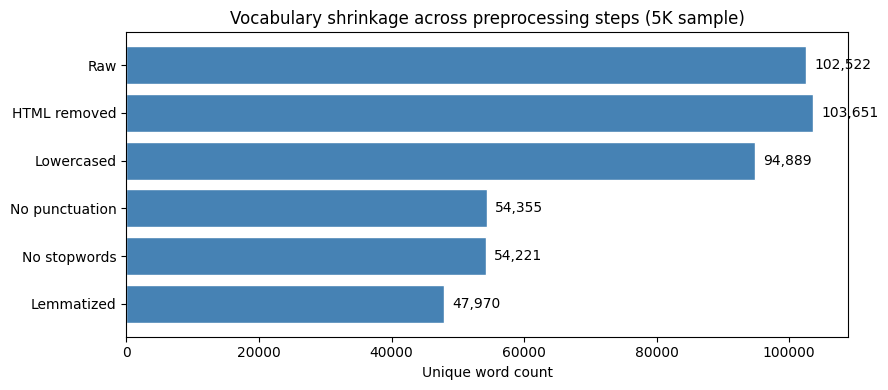

Saved -> C:\projects\imdb-sentiment-analysis\results\figures\vocabulary_shrinkage.png


In [8]:
# Vocabulary size at each preprocessing step (sample of 5,000 reviews for speed)
sample_reviews = df['review'].sample(5_000, random_state=42).astype(str)

raw_reviews = sample_reviews
html_removed_reviews = raw_reviews.map(prep.remove_html_tags)
lowercased_reviews = html_removed_reviews.map(prep.to_lowercase)
no_punctuation_reviews = lowercased_reviews.map(prep.remove_special_characters)
no_stopwords_reviews = no_punctuation_reviews.map(prep.remove_stopwords)
lemmatized_reviews = no_stopwords_reviews.map(prep.lemmatize_text)

stage_series = {
    'Raw': raw_reviews,
    'HTML removed': html_removed_reviews,
    'Lowercased': lowercased_reviews,
    'No punctuation': no_punctuation_reviews,
    'No stopwords': no_stopwords_reviews,
    'Lemmatized': lemmatized_reviews,
}

def vocab_size(series: pd.Series) -> int:
    vocab = set()
    for text in series:
        vocab.update(text.split())
    return len(vocab)

vocab_sizes = {}
for label, series in stage_series.items():
    size = vocab_size(series)
    vocab_sizes[label] = size
    print(f"{label:20s}: {size:>7,} unique words")

fig, ax = plt.subplots(figsize=(9, 4))
labels = list(vocab_sizes.keys())
sizes = list(vocab_sizes.values())
bars = ax.barh(labels, sizes, color='steelblue', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in sizes], padding=6, fontsize=10)
ax.set_xlabel('Unique word count')
ax.set_title('Vocabulary shrinkage across preprocessing steps (5K sample)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vocabulary_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_DIR / 'vocabulary_shrinkage.png'}")

**7. Apply to full dataset**  

We apply the pipeline to all 50,000 reviews and save the result to `data/imdb_preprocessed.csv`.  
This file is used as input for downstream notebooks, so we do not need to repeat preprocessing each time.

In [9]:
print("Applying preprocessing pipeline to all 50,000 reviews...")

review_values = df['review'].astype(str).tolist()
batch_size = 2000
processed_reviews = []

# progress bar
from tqdm.auto import tqdm

with tqdm(total=len(review_values), desc="Preprocessing", unit="review") as pbar:
    for start in range(0, len(review_values), batch_size):
        batch = review_values[start:start + batch_size]
        processed_reviews.extend(
            prep.preprocess_texts_batch(
                batch,
                batch_size=batch_size,
                progress_callback=pbar.update,
            )
        )

df['review_clean'] = processed_reviews

print(f"\nDone. Output shape: {df[['review_clean', 'sentiment']].shape}")
PREPROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df[['review_clean', 'sentiment']].to_csv(PREPROCESSED_DATA_PATH, index=False)
print(f"Saved -> {PREPROCESSED_DATA_PATH}")

df[['review_clean', 'sentiment']].head(3)

Applying preprocessing pipeline to all 50,000 reviews...


Preprocessing:   0%|          | 0/50000 [00:00<?, ?review/s]


Done. Output shape: (50000, 2)
Saved -> C:\projects\imdb-sentiment-analysis\data\imdb_preprocessed.csv


,review_clean,sentiment
0,one reviewer mention watch oz episode youll ho...,positive
1,wonderful little production film technique una...,positive
2,think wonderful way spend time hot summer week...,positive
